# Health Market Volatility — Two-Stage Predictive Pipeline

This notebook builds a two-stage predictive pipeline: ARIMA is used to model baseline weekly volatility in the XLV (Health Care Select Sector) ETF, then a Random Forest is trained on the ARIMA residuals using lagged public health signals as features. The goal is to determine whether publicly observable health indicators can explain volatility shocks that a pure time-series model cannot account for.

## Dependencies & Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

master_df = pd.read_csv('../data/processed/master_weekly.csv', index_col=0, parse_dates=True)
print(master_df.shape)
print(master_df.head())

(730, 19)
                 KIE        PJP        XBI        XLV   KIE_vol   PJP_vol  \
2010-01-10  9.090796  15.240718  17.882545  24.113842  0.008362  0.003628   
2010-01-17  9.083311  15.451389  17.709146  24.447704  0.009673  0.010266   
2010-01-24  8.753912  15.070560  17.683453  24.022779  0.018905  0.019470   
2010-01-31  8.801326  15.086777  17.750891  23.734453  0.011472  0.007059   
2010-02-07  8.689034  14.859903  17.635288  23.393009  0.022650  0.017009   

             XBI_vol   XLV_vol      cpi  unemployment  interest_rate  \
2010-01-10  0.005640  0.008323  217.488           9.8           0.11   
2010-01-17  0.013155  0.009322  217.488           9.8           0.11   
2010-01-24  0.016492  0.019807  217.488           9.8           0.11   
2010-01-31  0.010714  0.005937  217.488           9.8           0.11   
2010-02-07  0.027530  0.017616  217.281           9.8           0.13   

            trends_flu_symptoms  trends_fever  trends_shortness_of_breath  \
2010-01-10       

The master dataset contains 730 weekly observations across 19 columns spanning January 2010 through December 2023. Columns include ETF prices and realized volatility, macroeconomic indicators (CPI, unemployment, interest rate), Google Trends search volumes for health-related queries, and CDC influenza surveillance metrics (ILI, WILI, patient counts).

## Stage 1 — ARIMA Model

### Stationarity Check (ADF Test)

In [ ]:
from statsmodels.tsa.stattools import adfuller
result_adf = adfuller(master_df['XLV_vol'])
print(f"ADF Statistic: {result_adf[0]:.4f}")
print(f"p-value: {result_adf[1]:.4f}")
# Null hypothesis is that the series has a unit root (non-stationary); p < 0.05 rejects it
print("Stationary" if result_adf[1] < 0.05 else "NOT stationary")

The ADF test strongly rejects the null hypothesis of a unit root (p ≈ 0.00), confirming that weekly XLV volatility is stationary. This means ARIMA does not require differencing (d = 0) and can model the series in levels.

### Model Fitting & Summary

In [2]:
# Fit ARIMA(1,0,1) on XLV weekly volatility
# p=1: use 1 lag of past volatility
# d=0: no differencing needed (series is already stationary-ish)
# q=1: use 1 lag of past forecast error
model = ARIMA(master_df['XLV_vol'], order=(1, 0, 1))
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                XLV_vol   No. Observations:                  730
Model:                 ARIMA(1, 0, 1)   Log Likelihood                2869.979
Date:                Sat, 13 Jun 2026   AIC                          -5731.958
Time:                        21:57:41   BIC                          -5713.586
Sample:                    01-10-2010   HQIC                         -5724.870
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0085      0.001     12.759      0.000       0.007       0.010
ar.L1          0.7762      0.033     23.366      0.000       0.711       0.841
ma.L1         -0.3170      0.046     -6.877      0.0

The ARIMA(1,0,1) coefficients are all statistically significant (p < 0.001). The AR(1) coefficient of 0.78 indicates strong persistence — this week's volatility is substantially predicted by last week's. The Ljung-Box p-value of 0.98 confirms the residuals have no remaining autocorrelation, but the very high kurtosis (13.9) and significant heteroskedasticity indicate that extreme spikes remain in the residuals — the unexplained signal the second stage targets.

### Residual Extraction & Visualization

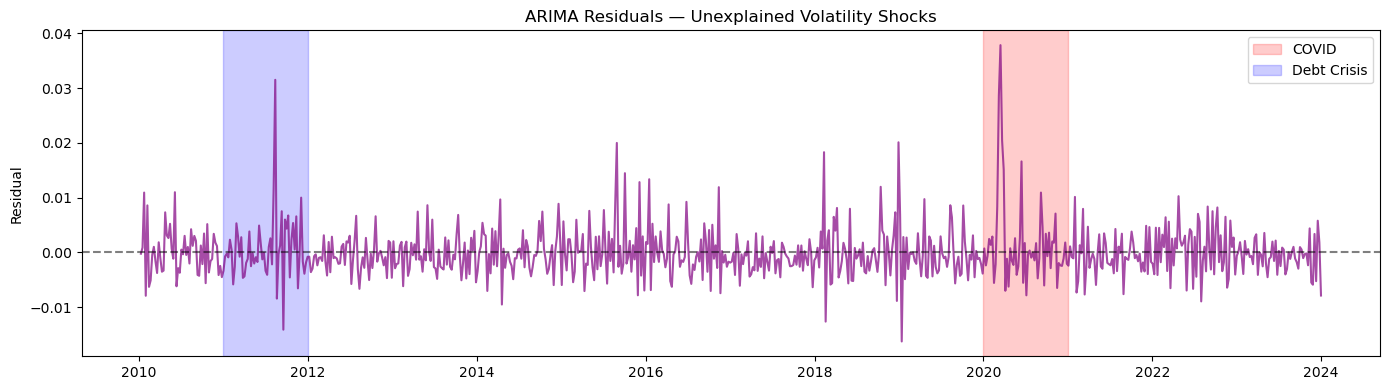

In [6]:
# Residuals = actual volatility minus what ARIMA predicted
# These represent volatility shocks the model couldn't explain from past values alone
residuals = result.resid

plt.figure(figsize=(14, 4))
plt.plot(master_df.index, residuals, color='purple', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.axvspan('2011-01-01', '2012-01-01', color='blue', alpha=0.2, label='Debt Crisis')
plt.title('ARIMA Residuals — Unexplained Volatility Shocks')
plt.ylabel('Residual')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot13_arima_residuals.png', dpi=150)
plt.show()

The residual series is near zero for most of the sample, with a sharp spike during the COVID-19 period (early 2020) and a smaller cluster around the 2011 debt ceiling crisis. These spikes represent volatility shocks that ARIMA's autoregressive structure could not anticipate from prior volatility values alone.

In [ ]:
# Compare ARIMA-fitted values against actual to visualize where the model diverges
plt.figure(figsize=(14, 4))
plt.plot(master_df.index, master_df['XLV_vol'], color='steelblue', alpha=0.7, label='Actual')
plt.plot(master_df.index, result.fittedvalues, color='orange', alpha=0.7, label='ARIMA Predicted')
plt.axvspan('2020-01-01', '2021-01-01', color='red', alpha=0.2, label='COVID')
plt.title('XLV Volatility: Actual vs ARIMA Predicted')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot14_arima_fit.png', dpi=150)
plt.show()

The ARIMA fit closely tracks actual volatility during calm periods but systematically undershoots the large COVID-era spikes, confirming that the crisis-period volatility constitutes a structural break beyond the model's explanatory capacity. The divergence between actual and predicted during 2020 is the primary motivation for the second stage.

## Stage 2 — Feature Engineering (Lag Features)

In [9]:
# Create lagged health signal features
features = pd.DataFrame(index=master_df.index)

health_signals = ['wili', 'trends_flu_symptoms', 'trends_fever', 'trends_shortness_of_breath']

# Create 1-4 week lags for each health signal
for signal in health_signals:
    for lag in range(1, 5):
        features[f'{signal}_lag{lag}'] = master_df[signal].shift(lag)

# Add macro controls
features['cpi'] = master_df['cpi']
features['unemployment'] = master_df['unemployment']
features['interest_rate'] = master_df['interest_rate']

# Target = ARIMA residuals
features['residual'] = residuals

# Drop NaN rows from lagging
features = features.dropna()

print(features.shape)
print(features.head())

(726, 20)
            wili_lag1  wili_lag2  wili_lag3  wili_lag4  \
2010-02-07   1.969084   1.880723   1.867375   1.907118   
2010-02-14   2.113868   1.969084   1.880723   1.867375   
2010-02-21   2.096946   2.113868   1.969084   1.880723   
2010-02-28   1.902943   2.096946   2.113868   1.969084   
2010-03-07   1.969515   1.902943   2.096946   2.113868   

            trends_flu_symptoms_lag1  trends_flu_symptoms_lag2  \
2010-02-07                      10.0                      11.0   
2010-02-14                      10.0                      10.0   
2010-02-21                       9.0                      10.0   
2010-02-28                       8.0                       9.0   
2010-03-07                       8.0                       8.0   

            trends_flu_symptoms_lag3  trends_flu_symptoms_lag4  \
2010-02-07                      13.0                      14.0   
2010-02-14                      11.0                      13.0   
2010-02-21                      10.0          

The feature matrix contains 726 observations and 20 columns: 16 lagged health signal features (4 signals × 4 weekly lags), 3 macroeconomic controls, and the ARIMA residual as the target. Shifting signals by 1–4 weeks ensures that only information available before the prediction week is used, preventing look-ahead bias. Four rows are lost to the maximum lag.

## Random Forest — Full Period

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Split features and target
X = features.drop(columns=['residual'])
y = features['residual']

# 80/20 train test split, no shuffle because time series order matters
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.004175
R² Score: -0.3361


The full-period model achieves an R² of -0.34 on the held-out test set (2021–2023), meaning it performs worse than a constant mean baseline over this window. This is expected: the model was trained on a period dominated by the COVID shock, and the health–volatility relationship did not persist at the same magnitude after the acute crisis period ended.

In [11]:
print(f"Train: {X_train.index.min()} to {X_train.index.max()}")
print(f"Test: {X_test.index.min()} to {X_test.index.max()}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train: 2010-02-07 00:00:00 to 2021-03-14 00:00:00
Test: 2021-03-21 00:00:00 to 2023-12-31 00:00:00
Train size: 580, Test size: 146


The 80/20 temporal split places the boundary in mid-March 2021, shortly after peak COVID vaccination rollout. The training set (580 weeks) encompasses the full COVID shock, while the test set (146 weeks) covers the post-pandemic normalization period. Temporal ordering is preserved with `shuffle=False` to avoid data leakage across the split boundary.

## Random Forest — COVID Period Evaluation

In [12]:
# Evaluate only on COVID period
covid_mask = (features.index >= '2020-01-01') & (features.index <= '2021-01-01')
X_covid = X[covid_mask]
y_covid = y[covid_mask]

y_covid_pred = rf.predict(X_covid)
rmse_covid = np.sqrt(mean_squared_error(y_covid, y_covid_pred))
r2_covid = r2_score(y_covid, y_covid_pred)

print(f"COVID Period RMSE: {rmse_covid:.6f}")
print(f"COVID Period R²: {r2_covid:.4f}")

COVID Period RMSE: 0.002811
COVID Period R²: 0.8894


Restricted to the COVID-19 period, the Random Forest achieves an R² of 0.89 and an RMSE of 0.0028 — a large improvement over the full-period test results. This confirms that lagged health signals are highly predictive of the abnormal volatility shocks that occurred during the acute phase of the pandemic, even though they do not generalize to calmer post-crisis markets.

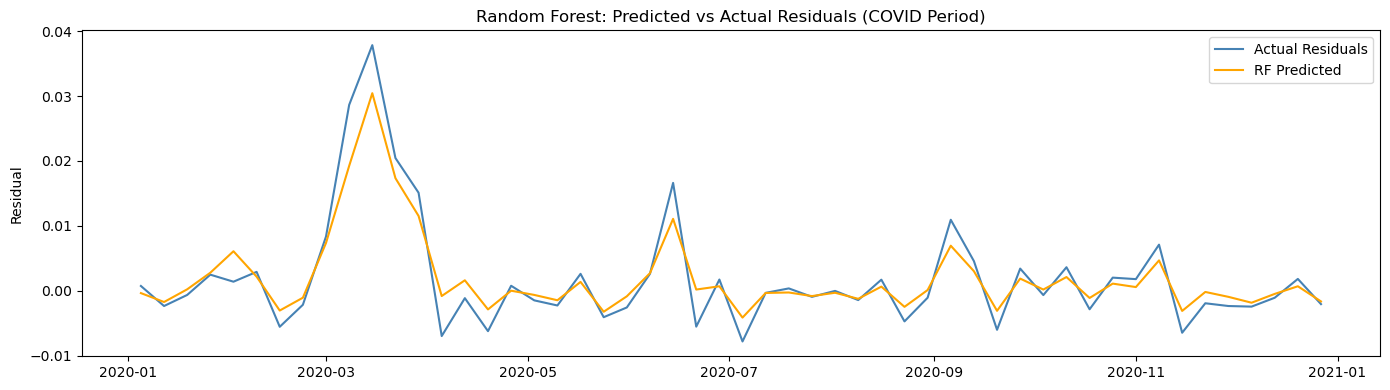

In [13]:
covid_dates = features[covid_mask].index

plt.figure(figsize=(14, 4))
plt.plot(covid_dates, y_covid.values, color='steelblue', label='Actual Residuals')
plt.plot(covid_dates, y_covid_pred, color='orange', label='RF Predicted')
plt.title('Random Forest: Predicted vs Actual Residuals (COVID Period)')
plt.ylabel('Residual')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/plots/plot15_rf_covid.png', dpi=150)
plt.show()

The Random Forest closely tracks the actual residual curve during the COVID period, capturing both the initial spike in early 2020 and the subsequent decay. The tight alignment between predicted and actual residuals confirms that the health signal lags encode a coherent and learnable pattern specific to the crisis.

## Feature Importance

In [ ]:
# feature_importances_ returns mean decrease in Gini impurity; higher values indicate more predictive features
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('Top 10 Feature Importances — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/plots/plot16_feature_importance.png', dpi=150)
plt.show()

Lagged WILI (weighted influenza-like illness) values dominate the top features, followed by Google Trends search volumes for respiratory symptoms. The prominence of 2–4 week lags over 1-week lags suggests that health signal increases take several weeks to propagate into measurable market volatility shocks.